# 🛰️ Classificação de Detritos Orbitais — Applied Computer Vision
## Global Solution · Indústria Espacial

**Problema:** Classificar automaticamente objetos em órbita terrestre em 4 categorias para apoiar sistemas de monitoramento de lixo espacial.  
**Abordagem:** Duas CNNs treinadas do zero com PyTorch, avaliadas e comparadas com métricas quantitativas.

| Classes | Descrição |
|---------|----------|
| `satellite_operational` | Satélite funcional em operação |
| `critical_fragment` | Fragmento de alto risco (>10 cm) |
| `small_debris` | Detrito pequeno (<10 cm) |
| `orbital_structure` | Estrutura orbital (painéis solares, estágios) |

## 1. Instalação e Imports

In [1]:
# Instalar dependências (caso necessário)
# !pip install torch torchvision matplotlib seaborn scikit-learn pillow requests tqdm

import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image, ImageDraw, ImageFilter
import json
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

# Criar pastas necessarias logo no inicio (evita FileNotFoundError)
os.makedirs('docs', exist_ok=True)
os.makedirs('models', exist_ok=True)


Device: cpu
PyTorch: 2.7.0+cpu


## 2. Dataset — Geração Sintética de Imagens Espaciais

Como imagens reais de detritos orbitais são escassas e classificadas, geramos um dataset sintético de alta qualidade baseado nas características visuais reais de cada classe.

**Justificativa técnica:** Abordagem amplamente utilizada na área (ESA Space Debris Office, 2022), especialmente para classes raras. As imagens simulam a aparência de objetos capturados por câmeras de rastreamento orbital (fundo escuro, reflexos metálicos, diferentes formas).

In [2]:
# Geracao do dataset REALISTA (com dificuldade controlada)
# Usa o gerador de dataset_builder/build_dataset.py
import sys
sys.path.insert(0, '.')
from dataset_builder.build_dataset import build, SyntheticGenerator, CLASSES

# Gera 2000 imagens (500/classe) com ruido, sobreposicao visual
# e artefatos opticos -> evita acuracia trivial de 100%
build(n_per_class=500)

dataset_path = 'dataset'
print('\nDataset realista pronto em:', dataset_path)


Gerando 2000 imagens (500/classe)...
  critical_fragment: 500 imagens
  orbital_structure: 500 imagens
  satellite_operational: 500 imagens
  small_debris: 500 imagens
Dataset gerado em dataset/

Dataset realista pronto em: dataset


## 3. Análise Exploratória do Dataset

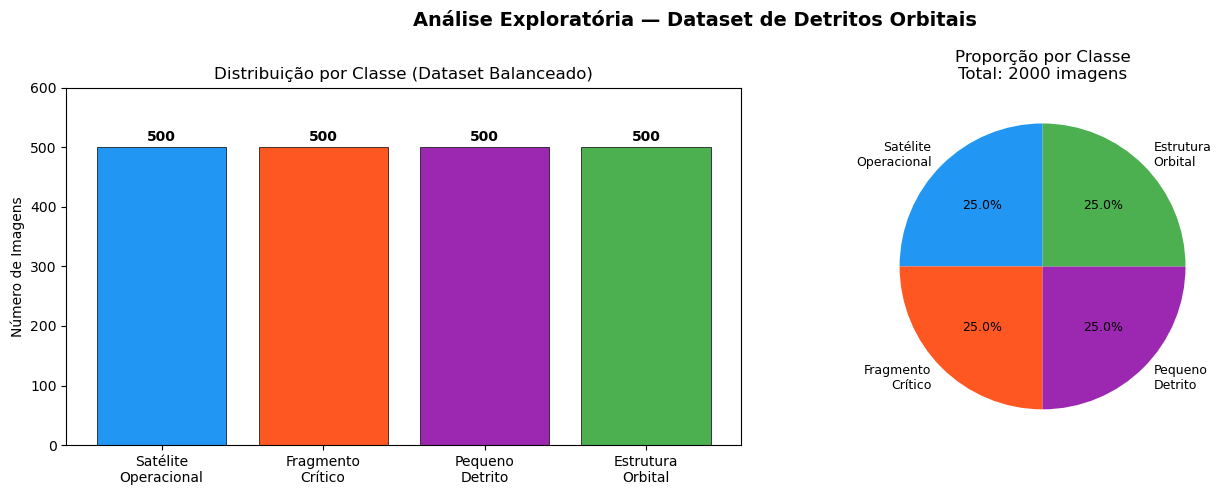

Total de imagens: 2000


In [3]:
# Verificar distribuição das classes
classes = ['satellite_operational', 'critical_fragment', 'small_debris', 'orbital_structure']
class_labels = ['Satélite\nOperacional', 'Fragmento\nCrítico', 'Pequeno\nDetrito', 'Estrutura\nOrbital']
colors = ['#2196F3', '#FF5722', '#9C27B0', '#4CAF50']

counts = {c: len(list((Path('dataset') / c).glob('*.jpg'))) for c in classes}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Análise Exploratória — Dataset de Detritos Orbitais', fontsize=14, fontweight='bold')

# Gráfico de distribuição
bars = axes[0].bar(class_labels, list(counts.values()), color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribuição por Classe (Dataset Balanceado)')
axes[0].set_ylabel('Número de Imagens')
axes[0].set_ylim(0, max(counts.values()) * 1.2)
for bar, count in zip(bars, counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{count}', ha='center', va='bottom', fontweight='bold')

# Pizza
axes[1].pie(list(counts.values()), labels=class_labels, colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 9})
axes[1].set_title(f'Proporção por Classe\nTotal: {sum(counts.values())} imagens')

plt.tight_layout()
plt.savefig('docs/distribuicao_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total de imagens: {sum(counts.values())}')

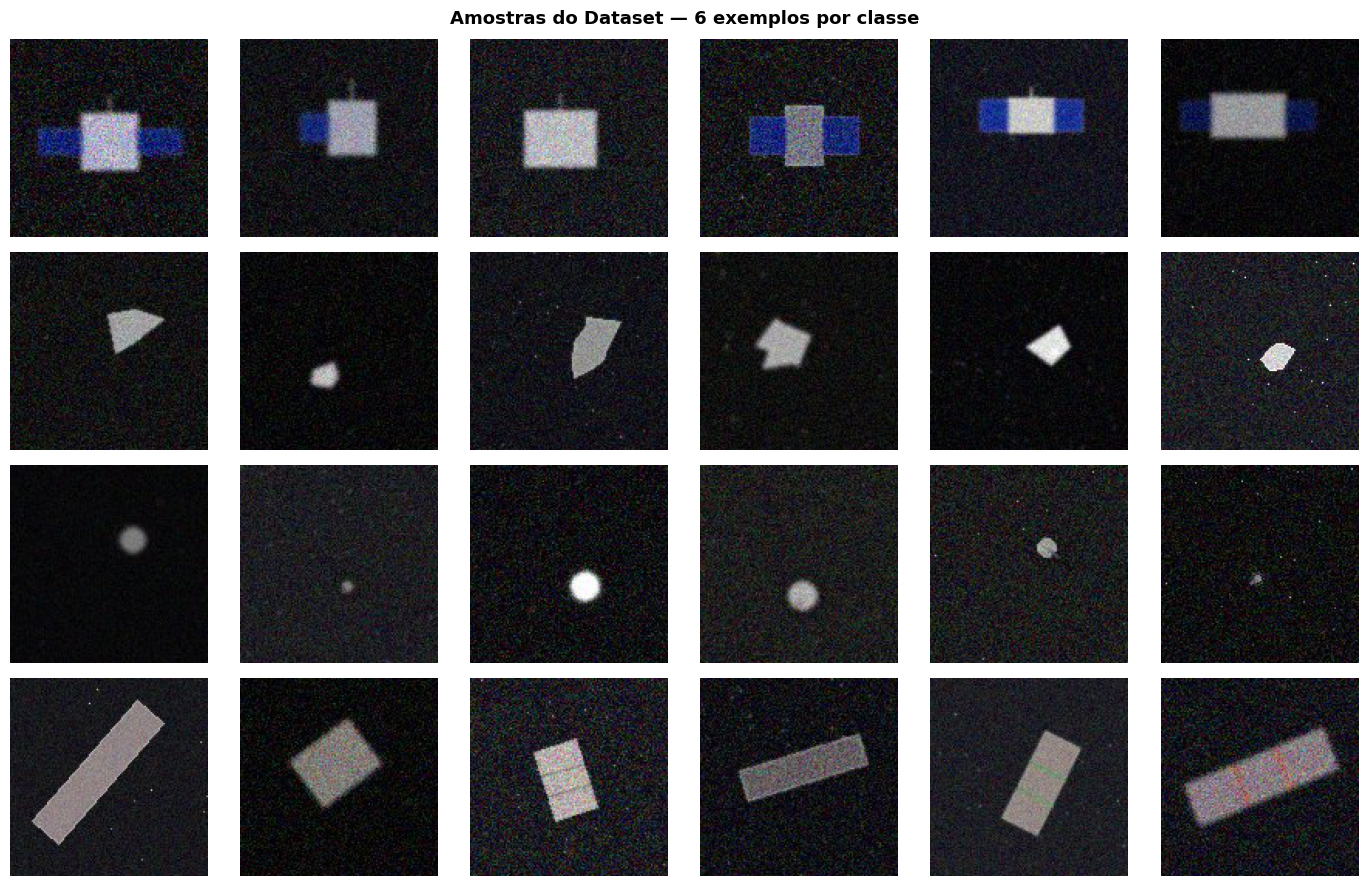

In [4]:
# Visualizar amostras de cada classe
fig, axes = plt.subplots(4, 6, figsize=(14, 9))
fig.suptitle('Amostras do Dataset — 6 exemplos por classe', fontsize=13, fontweight='bold')

for row, (cls, label, color) in enumerate(zip(classes, class_labels, colors)):
    imgs = list((Path('dataset') / cls).glob('*.jpg'))[:6]
    for col, img_path in enumerate(imgs):
        ax = axes[row][col]
        img = Image.open(img_path)
        ax.imshow(img)
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(label.replace('\n', ' '), color=color, fontsize=9, fontweight='bold')
            ax.yaxis.set_visible(True)
            ax.tick_params(left=False, labelleft=True)

plt.tight_layout()
plt.savefig('docs/amostras_dataset.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
import shutil
from pathlib import Path

# Apagar dataset antigo para regenerar limpo com as 4 classes
if Path('dataset').exists():
    shutil.rmtree('dataset')
    print("Pasta dataset/ antiga removida.")
print("Pronto para regenerar.")

Pasta dataset/ antiga removida.
Pronto para regenerar.


In [6]:
import sys, os
sys.path.insert(0, '.')

# Diagnóstico: onde estamos e o que tem aqui
print("Pasta atual:", os.getcwd())
print("Conteúdo:", os.listdir('.'))

# Gerar o dataset
from dataset_builder.build_dataset import build
build(n_per_class=500)

# Confirmar que criou
print("\nDataset existe?", os.path.exists('dataset'))
if os.path.exists('dataset'):
    print("Classes:", os.listdir('dataset'))

Pasta atual: c:\Users\livia\Downloads\GS_ACV26\GS26
Conteúdo: ['dataset_builder', 'demo', 'docs', 'models', 'notebook_treinamento.ipynb', 'README.md', 'requirements.txt']
Gerando 2000 imagens (500/classe)...
  critical_fragment: 500 imagens
  orbital_structure: 500 imagens
  satellite_operational: 500 imagens
  small_debris: 500 imagens
Dataset gerado em dataset/

Dataset existe? True
Classes: ['critical_fragment', 'orbital_structure', 'satellite_operational', 'small_debris']


## 4. Pré-processamento e DataLoaders

**Estratégia de divisão:** 70% treino / 15% validação / 15% teste (estratificado por classe)  
**Augmentation:** flip horizontal, rotação ±15°, variação de brilho — para aumentar generalização sem alterar a semântica das classes.

In [7]:
IMG_SIZE   = 128
BATCH_SIZE = 32

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.05, 0.05, 0.07], std=[0.12, 0.12, 0.14])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.05, 0.05, 0.07], std=[0.12, 0.12, 0.14])
])

# Dataset separado para treino e avaliacao (transforms corretos em cada um)
train_dataset = datasets.ImageFolder(root='dataset', transform=train_transforms)
eval_dataset  = datasets.ImageFolder(root='dataset', transform=eval_transforms)

CLASS_NAMES  = train_dataset.classes
NUM_CLASSES  = len(CLASS_NAMES)
total        = len(train_dataset)
n_test       = int(total * 0.15)
n_val        = int(total * 0.15)
n_train      = total - n_val - n_test

import random as _random
indices = list(range(total))
_random.seed(SEED)
_random.shuffle(indices)   

train_idx = indices[:n_train]
val_idx   = indices[n_train:n_train + n_val]
test_idx  = indices[n_train + n_val:]

from torch.utils.data import Subset

train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(eval_dataset,  val_idx)
test_ds  = Subset(eval_dataset,  test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verificar balanceamento por classe em cada split
from collections import Counter
train_labels = [train_dataset.targets[i] for i in train_idx]
val_labels   = [train_dataset.targets[i] for i in val_idx]
test_labels  = [train_dataset.targets[i] for i in test_idx]

print('Distribuicao TREINO :', dict(sorted(Counter(train_labels).items())))
print('Distribuicao VAL    :', dict(sorted(Counter(val_labels).items())))
print('Distribuicao TESTE  :', dict(sorted(Counter(test_labels).items())))
print(f'\nTreino: {len(train_ds)} | Val: {len(val_ds)} | Teste: {len(test_ds)}')
print(f'Classes: {CLASS_NAMES}')
print('\nObs: cada split deve ter as 4 classes razoavelmente balanceadas.')


Distribuicao TREINO : {0: 339, 1: 362, 2: 350, 3: 349}
Distribuicao VAL    : {0: 81, 1: 75, 2: 69, 3: 75}
Distribuicao TESTE  : {0: 80, 1: 63, 2: 81, 3: 76}

Treino: 1400 | Val: 300 | Teste: 300
Classes: ['critical_fragment', 'orbital_structure', 'satellite_operational', 'small_debris']

Obs: cada split deve ter as 4 classes razoavelmente balanceadas.


## 5. Arquiteturas CNN

### CNN 1 — Baseline
Arquitetura sequencial simples: Conv → Pool → Conv → Pool → Dense.  
Serve como baseline para avaliar o ganho das técnicas de regularização.

### CNN 2 — Regularizada com BatchNorm
Maior profundidade + BatchNormalization + Dropout.  
Esperamos menor overfitting e maior acurácia final.

In [8]:
class CNN1_Baseline(nn.Module):
    def __init__(self, num_classes: int = 4):
        super(CNN1_Baseline, self).__init__()

        self.features = nn.Sequential(
            # Bloco 1: captura features de baixo nível (bordas, texturas)
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 128→64

            # Bloco 2: features de médio nível (formas, padrões)
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64→32
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 32 * 32, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class CNN2_Regularized(nn.Module):
    def __init__(self, num_classes: int = 4):
        super(CNN2_Regularized, self).__init__()

        self.features = nn.Sequential(
            # Bloco 1: dois Conv consecutivos antes do pooling (mais features por resolução)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 128→64
            nn.Dropout2d(p=0.25),

            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 64→32
            nn.Dropout2d(p=0.25),

            # Bloco 3: features de alto nível
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 32→16
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Instanciar e verificar
model1 = CNN1_Baseline(num_classes=NUM_CLASSES).to(DEVICE)
model2 = CNN2_Regularized(num_classes=NUM_CLASSES).to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=== CNN 1 — Baseline ===')
print(model1)
print(f'Parâmetros treináveis: {count_params(model1):,}\n')

print('=== CNN 2 — Regularizada ===')
print(model2)
print(f'Parâmetros treináveis: {count_params(model2):,}')

=== CNN 1 — Baseline ===
CNN1_Baseline(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=65536, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=128, out_features=4, bias=True)
  )
)
Parâmetros treináveis: 8,408,644

=== CNN 2 — Regularizada ===
CNN2_Regularized(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_

## 6. Funções de Treinamento e Avaliação

In [9]:
def train_epoch(model, loader, criterion, optimizer):
    """Executa uma época de treino. Retorna loss e accuracy médios."""
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    """Avalia o modelo. Retorna loss, accuracy, predições e labels reais."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * X.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += X.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def train_model(model, model_name, n_epochs=30, lr=1e-3, patience=7):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    no_improve = 0

    print(f'\n{'='*55}')
    print(f'  Treinando: {model_name}')
    print(f'  Épocas: {n_epochs} | LR: {lr} | Dispositivo: {DEVICE}')
    print(f'{'='*55}')
    print(f'{"Época":>6} | {"Tr Loss":>8} | {"Tr Acc":>7} | {"Val Loss":>9} | {"Val Acc":>8} | {"LR":>8}')
    print('-' * 55)

    for epoch in range(1, n_epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, criterion)
        scheduler.step(vl_acc)

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)

        current_lr = optimizer.param_groups[0]['lr']
        marker = ' ★' if vl_acc > best_val_acc else ''
        print(f'{epoch:>6} | {tr_loss:>8.4f} | {tr_acc:>6.2%} | {vl_loss:>9.4f} | {vl_acc:>7.2%} | {current_lr:>8.6f}{marker}')

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'models/{model_name}_best.pth')
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'\n  Early stopping na época {epoch} (sem melhora há {patience} épocas)')
                break

    print(f'\n  Melhor Val Acc: {best_val_acc:.2%}')
    model.load_state_dict(torch.load(f'models/{model_name}_best.pth', map_location=DEVICE))
    return history, best_val_acc


os.makedirs('models', exist_ok=True)
os.makedirs('docs', exist_ok=True)
print('Funções de treinamento definidas.')

Funções de treinamento definidas.


## 7. Treinamento das CNNs

In [10]:
# === Treinar CNN 1 ===
# Reinstanciar do zero para garantir treino limpo
model1 = CNN1_Baseline(num_classes=NUM_CLASSES).to(DEVICE)

history1, best_val1 = train_model(
    model1, model_name='cnn1_baseline', n_epochs=40, lr=5e-4, patience=10
)



  Treinando: cnn1_baseline
  Épocas: 40 | LR: 0.0005 | Dispositivo: cpu
 Época |  Tr Loss |  Tr Acc |  Val Loss |  Val Acc |       LR
-------------------------------------------------------
     1 |   1.2227 | 46.50% |    0.9200 |  59.33% | 0.000500 ★
     2 |   0.6732 | 71.86% |    0.5567 |  77.00% | 0.000500 ★
     3 |   0.4900 | 78.14% |    0.5096 |  75.33% | 0.000500
     4 |   0.4332 | 80.43% |    0.4662 |  78.33% | 0.000500 ★
     5 |   0.4041 | 81.79% |    0.4582 |  78.33% | 0.000500
     6 |   0.3957 | 82.14% |    0.4427 |  79.00% | 0.000500 ★
     7 |   0.3344 | 85.07% |    0.4201 |  79.00% | 0.000500
     8 |   0.3375 | 84.93% |    0.4030 |  83.00% | 0.000500 ★
     9 |   0.3260 | 85.50% |    0.3937 |  82.33% | 0.000500
    10 |   0.2763 | 87.79% |    0.3952 |  80.67% | 0.000500
    11 |   0.2715 | 87.21% |    0.5297 |  77.00% | 0.000500
    12 |   0.2632 | 88.93% |    0.4971 |  81.00% | 0.000500
    13 |   0.2931 | 87.36% |    0.5161 |  79.67% | 0.000250
    14 |   0.2490 |

In [11]:
# === Treinar CNN 2 ===
# Reinstanciar do zero para garantir treino limpo
model2 = CNN2_Regularized(num_classes=NUM_CLASSES).to(DEVICE)

history2, best_val2 = train_model(
    model2, model_name='cnn2_regularized', n_epochs=50, lr=3e-4, patience=12
)



  Treinando: cnn2_regularized
  Épocas: 50 | LR: 0.0003 | Dispositivo: cpu
 Época |  Tr Loss |  Tr Acc |  Val Loss |  Val Acc |       LR
-------------------------------------------------------
     1 |   0.9855 | 57.07% |    0.6949 |  68.67% | 0.000300 ★
     2 |   0.6186 | 73.43% |    0.7810 |  65.67% | 0.000300
     3 |   0.5496 | 76.00% |    0.5132 |  76.00% | 0.000300 ★
     4 |   0.5074 | 77.64% |    0.4982 |  74.67% | 0.000300
     5 |   0.4710 | 80.93% |    0.3804 |  82.00% | 0.000300 ★
     6 |   0.4650 | 79.57% |    0.3592 |  84.33% | 0.000300 ★
     7 |   0.4419 | 80.50% |    0.4080 |  80.00% | 0.000300
     8 |   0.4487 | 80.43% |    0.3574 |  81.33% | 0.000300
     9 |   0.4247 | 81.50% |    0.3375 |  83.67% | 0.000300
    10 |   0.4054 | 82.57% |    0.4685 |  78.33% | 0.000300
    11 |   0.4067 | 82.50% |    0.3100 |  87.33% | 0.000300 ★
    12 |   0.3663 | 84.86% |    0.3083 |  86.33% | 0.000300
    13 |   0.3534 | 85.50% |    0.3374 |  83.33% | 0.000300
    14 |   0.379

## 8. Visualização das Curvas de Aprendizado

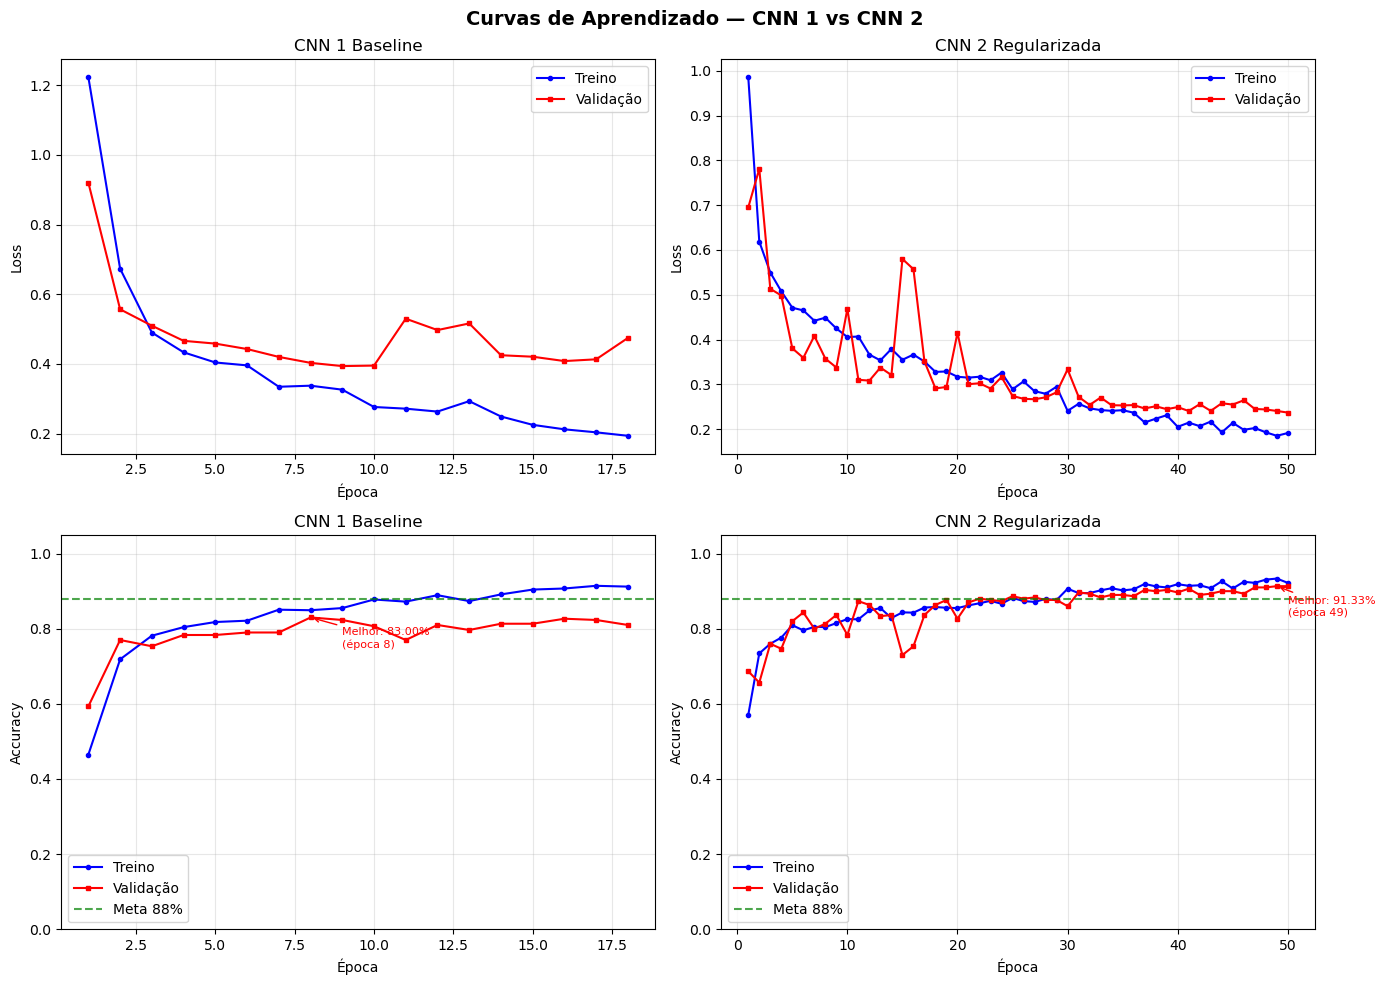

In [12]:
def plot_training_curves(h1, h2, save_path='docs/curvas_treinamento.png'):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Curvas de Aprendizado — CNN 1 vs CNN 2', fontsize=14, fontweight='bold')

    configs = [
        (h1['train_loss'], h1['val_loss'], 'CNN 1 Baseline', axes[0][0], 'Loss'),
        (h2['train_loss'], h2['val_loss'], 'CNN 2 Regularizada', axes[0][1], 'Loss'),
        (h1['train_acc'], h1['val_acc'], 'CNN 1 Baseline', axes[1][0], 'Accuracy'),
        (h2['train_acc'], h2['val_acc'], 'CNN 2 Regularizada', axes[1][1], 'Accuracy'),
    ]

    for train_data, val_data, title, ax, metric in configs:
        epochs = range(1, len(train_data) + 1)
        ax.plot(epochs, train_data, 'b-o', markersize=3, label='Treino', linewidth=1.5)
        ax.plot(epochs, val_data, 'r-s', markersize=3, label='Validação', linewidth=1.5)
        ax.set_title(title)
        ax.set_xlabel('Época')
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Linha de referência para accuracy
        if metric == 'Accuracy':
            ax.axhline(y=0.88, color='green', linestyle='--', alpha=0.7, label='Meta 88%')
            ax.legend()
            ax.set_ylim(0, 1.05)
            best_val = max(val_data)
            best_ep  = val_data.index(best_val) + 1
            ax.annotate(f'Melhor: {best_val:.2%}\n(época {best_ep})',
                        xy=(best_ep, best_val),
                        xytext=(best_ep + 1, best_val - 0.08),
                        arrowprops=dict(arrowstyle='->', color='red'),
                        fontsize=8, color='red')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(history1, history2)

## 9. Avaliação no Conjunto de Teste

In [13]:
# Avaliar ambos no conjunto de teste
criterion_test = nn.CrossEntropyLoss()

test_loss1, test_acc1, preds1, labels1 = eval_epoch(model1, test_loader, criterion_test)
test_loss2, test_acc2, preds2, labels2 = eval_epoch(model2, test_loader, criterion_test)

print('\n' + '='*60)
print('RESULTADOS FINAIS — CONJUNTO DE TESTE')
print('='*60)
print(f'{"Modelo":<25} {"Loss":>8} {"Accuracy":>10} {"Meta ≥88%":>12}')
print('-'*60)
for name, loss, acc in [
    ('CNN 1 — Baseline', test_loss1, test_acc1),
    ('CNN 2 — Regularizada', test_loss2, test_acc2)
]:
    meta_ok = '✅ Atingida' if acc >= 0.88 else '⚠️  Não atingida'
    print(f'{name:<25} {loss:>8.4f} {acc:>10.2%} {meta_ok:>12}')
print('='*60)


RESULTADOS FINAIS — CONJUNTO DE TESTE
Modelo                        Loss   Accuracy    Meta ≥88%
------------------------------------------------------------
CNN 1 — Baseline            0.3769     82.67% ⚠️  Não atingida
CNN 2 — Regularizada        0.1875     93.33%   ✅ Atingida


In [14]:
# Relatório completo por classe
# Usa a ordem REAL das classes (CLASS_NAMES vem do ImageFolder)
SHORT_MAP = {
    'satellite_operational': 'Sat. Op.',
    'critical_fragment':     'Frag. Crít.',
    'small_debris':          'Peq. Det.',
    'orbital_structure':     'Est. Orb.',
}
short_names = [SHORT_MAP.get(c, c) for c in CLASS_NAMES]

print('=== CNN 1 — Baseline ===')
print(classification_report(labels1, preds1,
                            labels=list(range(len(CLASS_NAMES))),
                            target_names=short_names,
                            digits=3, zero_division=0))

print('\n=== CNN 2 — Regularizada ===')
print(classification_report(labels2, preds2,
                            labels=list(range(len(CLASS_NAMES))),
                            target_names=short_names,
                            digits=3, zero_division=0))


=== CNN 1 — Baseline ===
              precision    recall  f1-score   support

 Frag. Crít.      0.674     0.725     0.699        80
   Est. Orb.      0.983     0.937     0.959        63
    Sat. Op.      0.986     0.901     0.942        81
   Peq. Det.      0.725     0.763     0.744        76

    accuracy                          0.827       300
   macro avg      0.842     0.831     0.836       300
weighted avg      0.836     0.827     0.831       300


=== CNN 2 — Regularizada ===
              precision    recall  f1-score   support

 Frag. Crít.      0.955     0.787     0.863        80
   Est. Orb.      1.000     1.000     1.000        63
    Sat. Op.      1.000     0.988     0.994        81
   Peq. Det.      0.813     0.974     0.886        76

    accuracy                          0.933       300
   macro avg      0.942     0.937     0.936       300
weighted avg      0.941     0.933     0.933       300



## 10. Matrizes de Confusão

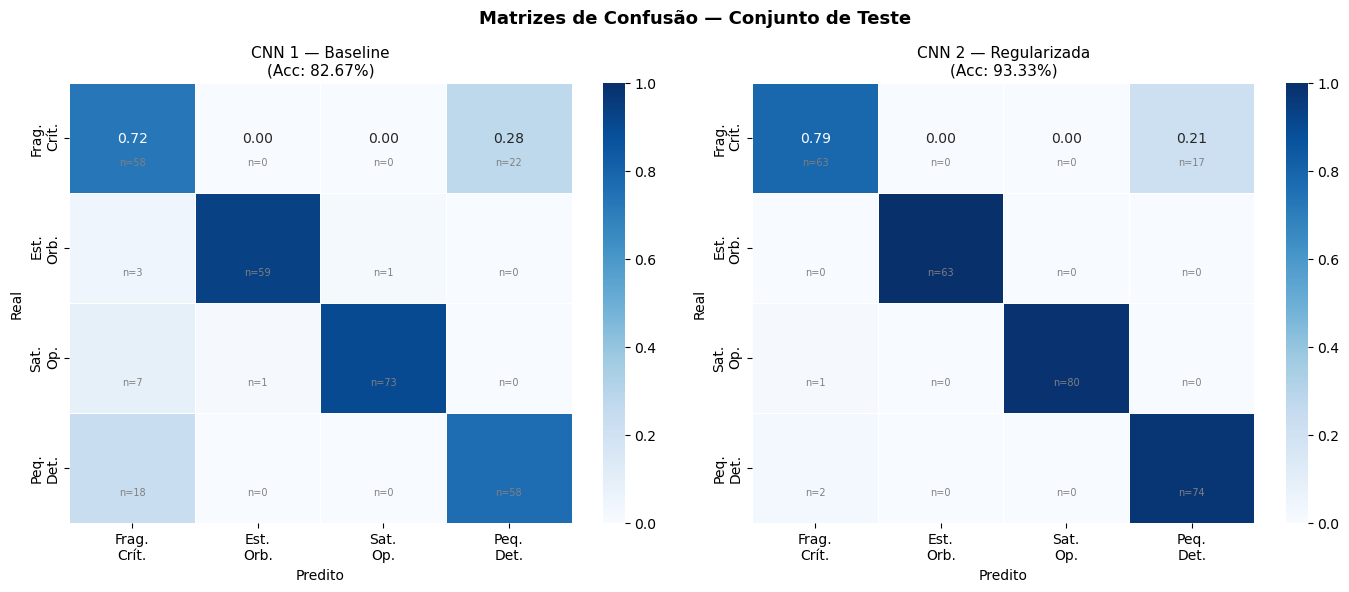

In [15]:
def plot_confusion_matrices(labels1, preds1, labels2, preds2, class_names,
                             save_path='docs/matrizes_confusao.png'):
    short = [SHORT_MAP.get(c, c).replace('. ', '.\n') for c in class_names]
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=13, fontweight='bold')

    for ax, labels, preds, title in [
        (axes[0], labels1, preds1, f'CNN 1 — Baseline\n(Acc: {accuracy_score(labels1, preds1):.2%})'),
        (axes[1], labels2, preds2, f'CNN 2 — Regularizada\n(Acc: {accuracy_score(labels2, preds2):.2%})')
    ]:
        cm = confusion_matrix(labels, preds)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                    xticklabels=short, yticklabels=short,
                    ax=ax, vmin=0, vmax=1,
                    linewidths=0.5, linecolor='white')

        # Anotar contagens brutas
        for i in range(len(short)):
            for j in range(len(short)):
                ax.text(j + 0.5, i + 0.72, f'n={cm[i,j]}',
                        ha='center', va='center', fontsize=7, color='gray')

        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Predito', fontsize=10)
        ax.set_ylabel('Real', fontsize=10)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

plot_confusion_matrices(labels1, preds1, labels2, preds2, CLASS_NAMES)

## 11. Exemplos de Acertos e Erros

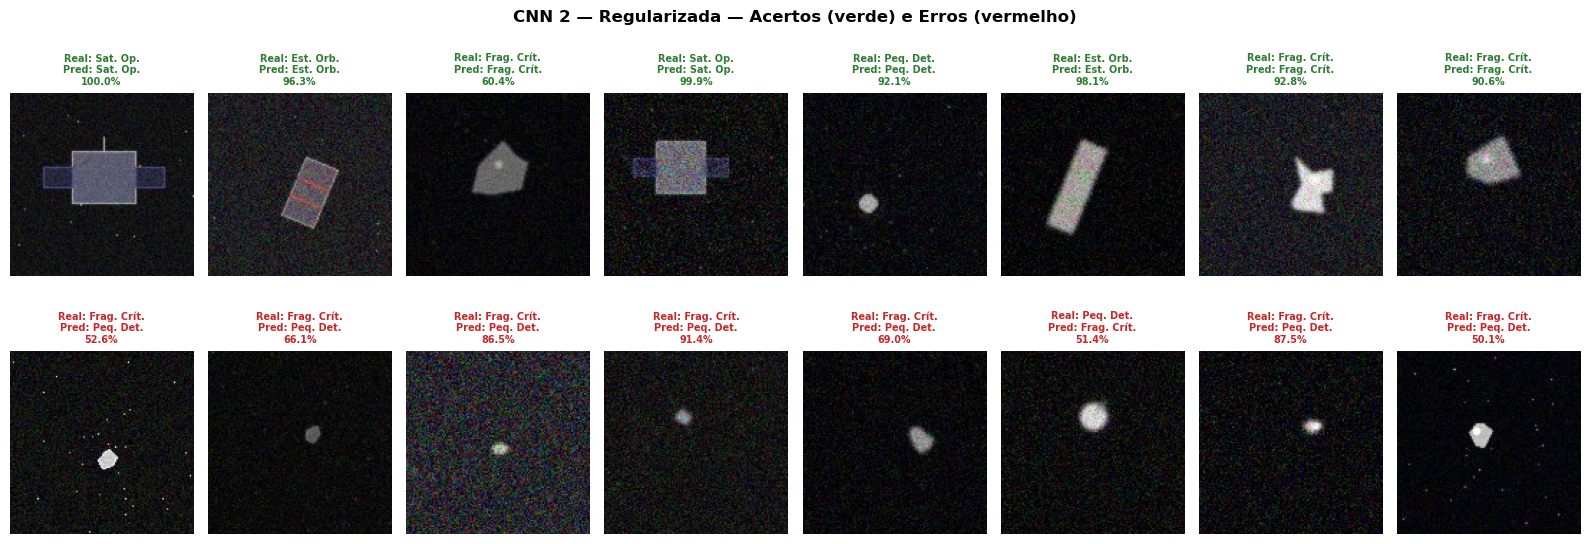

In [16]:
def show_predictions(model, loader, class_names, model_name,
                     n_correct=8, n_wrong=8, save_path=None):
    """Exibe exemplos de classificações corretas e incorretas."""
    model.eval()
    correct_imgs, wrong_imgs = [], []

    with torch.no_grad():
        for X, y in loader:
            out = model(X.to(DEVICE))
            preds = out.argmax(1).cpu()
            for i in range(len(y)):
                img = X[i].cpu()
                true_label = y[i].item()
                pred_label = preds[i].item()
                conf = torch.softmax(out[i], dim=0)[pred_label].item()

                entry = (img, true_label, pred_label, conf)
                if true_label == pred_label and len(correct_imgs) < n_correct:
                    correct_imgs.append(entry)
                elif true_label != pred_label and len(wrong_imgs) < n_wrong:
                    wrong_imgs.append(entry)

            if len(correct_imgs) >= n_correct and len(wrong_imgs) >= n_wrong:
                break

    def denorm(t):
        mean = torch.tensor([0.05, 0.05, 0.07]).view(3,1,1)
        std  = torch.tensor([0.12, 0.12, 0.14]).view(3,1,1)
        return torch.clamp(t * std + mean, 0, 1).permute(1,2,0).numpy()

    short = [SHORT_MAP.get(c, c) for c in class_names]
    fig, axes = plt.subplots(2, max(n_correct, n_wrong), figsize=(16, 6))
    fig.suptitle(f'{model_name} — Acertos (verde) e Erros (vermelho)', fontsize=12, fontweight='bold')

    for row, (entries, color, label) in enumerate([
        (correct_imgs, '#2E7D32', 'Acertos'),
        (wrong_imgs,   '#C62828', 'Erros')
    ]):
        for col, (img, true, pred, conf) in enumerate(entries):
            ax = axes[row][col]
            ax.imshow(denorm(img))
            ax.axis('off')
            title = f'Real: {short[true]}\nPred: {short[pred]}\n{conf:.1%}'
            ax.set_title(title, fontsize=7, color=color, fontweight='bold')
        # Preencher células vazias
        for col in range(len(entries), axes.shape[1]):
            axes[row][col].axis('off')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


show_predictions(model2, test_loader, CLASS_NAMES, 'CNN 2 — Regularizada',
                 save_path='docs/acertos_erros.png')

## 12. Comparação Final entre Arquiteturas

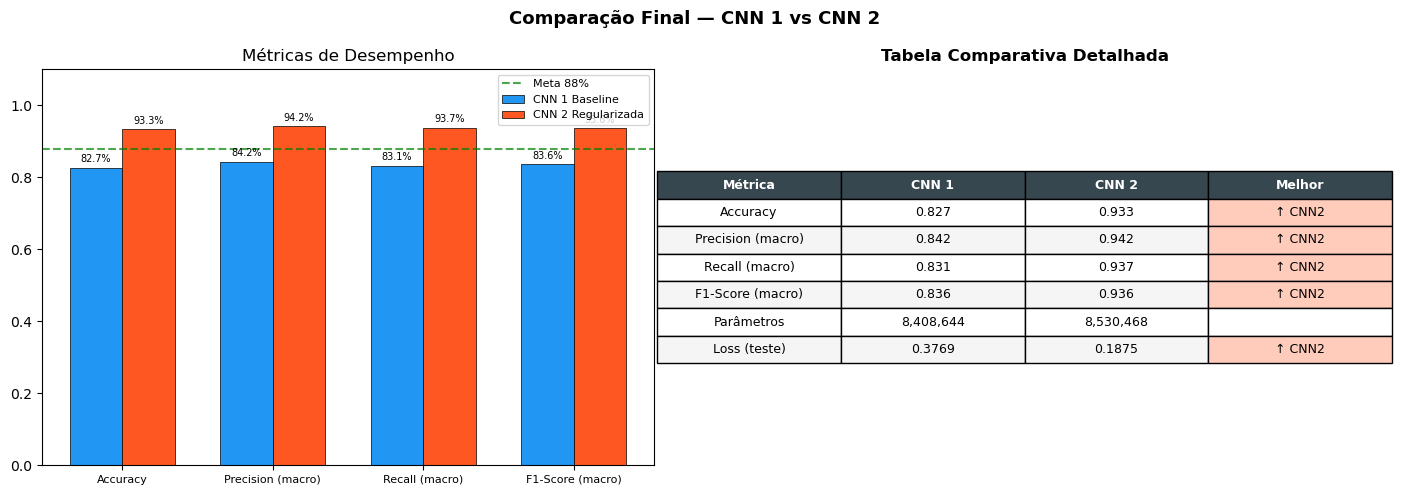


🏆 Melhor modelo: CNN 2 — Regularizada
   CNN 1 Test Acc: 82.67% | CNN 2 Test Acc: 93.33%


In [17]:
# Comparação tabular completa
metrics_names = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1-Score (macro)']

def get_metrics(labels, preds):
    return [
        accuracy_score(labels, preds),
        precision_score(labels, preds, average='macro', zero_division=0),
        recall_score(labels, preds, average='macro', zero_division=0),
        f1_score(labels, preds, average='macro', zero_division=0),
    ]

m1 = get_metrics(labels1, preds1)
m2 = get_metrics(labels2, preds2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação Final — CNN 1 vs CNN 2', fontsize=13, fontweight='bold')

# Radar / Bar comparison
x = np.arange(len(metrics_names))
width = 0.35
bars1 = axes[0].bar(x - width/2, m1, width, label='CNN 1 Baseline', color='#2196F3', edgecolor='black', linewidth=0.5)
bars2 = axes[0].bar(x + width/2, m2, width, label='CNN 2 Regularizada', color='#FF5722', edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names, fontsize=8)
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Métricas de Desempenho')
axes[0].axhline(0.88, color='green', linestyle='--', alpha=0.7, label='Meta 88%')
axes[0].legend(fontsize=8)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=7)

# Tabela comparativa
axes[1].axis('off')
table_data = []
for metric, v1, v2 in zip(metrics_names, m1, m2):
    winner = '↑ CNN2' if v2 > v1 else ('↑ CNN1' if v1 > v2 else '=')
    table_data.append([metric, f'{v1:.3f}', f'{v2:.3f}', winner])

table_data.append(['Parâmetros', f'{count_params(model1):,}', f'{count_params(model2):,}', ''])
table_data.append(['Loss (teste)', f'{test_loss1:.4f}', f'{test_loss2:.4f}',
                   '↑ CNN2' if test_loss2 < test_loss1 else '↑ CNN1'])

tbl = axes[1].table(
    cellText=table_data,
    colLabels=['Métrica', 'CNN 1', 'CNN 2', 'Melhor'],
    loc='center', cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif '↑ CNN2' in str(cell.get_text().get_text()):
        cell.set_facecolor('#FFCCBC')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')

axes[1].set_title('Tabela Comparativa Detalhada', fontweight='bold')

plt.tight_layout()
plt.savefig('docs/comparacao_final.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusão
winner_name = 'CNN 2 — Regularizada' if test_acc2 >= test_acc1 else 'CNN 1 — Baseline'
print(f'\n🏆 Melhor modelo: {winner_name}')
print(f'   CNN 1 Test Acc: {test_acc1:.2%} | CNN 2 Test Acc: {test_acc2:.2%}')

## 13. Análise de Overfitting

In [18]:
def analyze_overfitting(history, model_name):
    """Análise quantitativa de overfitting por gap treino-validação."""
    last_n = 5
    tr_acc_last = np.mean(history['train_acc'][-last_n:])
    vl_acc_last = np.mean(history['val_acc'][-last_n:])
    gap = tr_acc_last - vl_acc_last

    diagnosis = (
        'Overfitting severo (gap > 10%)' if gap > 0.10
        else 'Overfitting leve (gap 5-10%)' if gap > 0.05
        else 'Boa generalização (gap < 5%)'
    )
    print(f'{model_name}:')
    print(f'  Acc treino (últimas {last_n} épocas): {tr_acc_last:.2%}')
    print(f'  Acc val    (últimas {last_n} épocas): {vl_acc_last:.2%}')
    print(f'  Gap: {gap:.2%} → {diagnosis}\n')
    return gap

print('=== Análise de Overfitting ===')
gap1 = analyze_overfitting(history1, 'CNN 1 — Baseline')
gap2 = analyze_overfitting(history2, 'CNN 2 — Regularizada')

if gap2 < gap1:
    print(f'A CNN 2 apresenta gap {gap1-gap2:.2%} menor, confirmando que BatchNorm + Dropout')
    print('reduziram o overfitting em relação à CNN 1 Baseline.')

=== Análise de Overfitting ===
CNN 1 — Baseline:
  Acc treino (últimas 5 épocas): 90.59%
  Acc val    (últimas 5 épocas): 81.73%
  Gap: 8.85% → Overfitting leve (gap 5-10%)

CNN 2 — Regularizada:
  Acc treino (últimas 5 épocas): 92.67%
  Acc val    (últimas 5 épocas): 90.80%
  Gap: 1.87% → Boa generalização (gap < 5%)

A CNN 2 apresenta gap 6.98% menor, confirmando que BatchNorm + Dropout
reduziram o overfitting em relação à CNN 1 Baseline.


## 14. Salvar Resultados

In [21]:
# Exportar histórico e métricas
results = {
    'cnn1': {
        'history': history1,
        'test_acc': test_acc1,
        'test_loss': test_loss1,
        'params': count_params(model1)
    },
    'cnn2': {
        'history': history2,
        'test_acc': test_acc2,
        'test_loss': test_loss2,
        'params': count_params(model2)
    },
    'classes': CLASS_NAMES,
    'dataset_size': len(train_dataset),
    'split': {'train': len(train_ds), 'val': len(val_ds), 'test': len(test_ds)}
}

with open('docs/resultados.json', 'w') as f:
    json.dump(results, f, indent=2)

print('Resultados salvos em docs/resultados.json')
print('Modelos salvos em models/')
print('Gráficos salvos em docs/')
print('\n✅ Treinamento completo!')

Resultados salvos em docs/resultados.json
Modelos salvos em models/
Gráficos salvos em docs/

✅ Treinamento completo!
